In [2]:
#모듈 import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [127]:
# 데이터 로딩

df = pd.read_csv('/content/drive/MyDrive/KDThome/spaceship-titanic/train.csv')
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [128]:
# 불필요한 컬럼 제거
df_1 = df.drop(['Name'], axis=1, inplace=False)
df_1

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False


In [129]:
print(df_1.isnull().sum())
print(df_1.shape)  #(8693, 8)


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
dtype: int64
(8693, 13)


In [130]:
# 컬럼별 데이터 정리
# 1. HomePlanet  결측치: 최빈값
print(df_1['HomePlanet'].value_counts())

df_1['HomePlanet'] = df_1['HomePlanet'].fillna(df_1['HomePlanet'].mode()[0])

df_1_HomePlanet_encoded = pd.get_dummies(df_1['HomePlanet'], prefix='HomePlanet').astype(int)
df_2 = pd.concat([df_1,df_1_HomePlanet_encoded], axis=1)
df_3 = df_2.drop('HomePlanet', axis=1, inplace=False)

df_3.isnull().sum()

HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64


,0
PassengerId,0
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208
Spa,183


In [160]:
# Cabin
# 컬럼 분리
#print(df_3['Cabin'].value_counts())
df_3[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_3['Cabin'].str.split('/', expand=True)

# 결측치 처리 최빈값
df_3['Cabin_Deck'] = df_3['Cabin_Deck'].fillna(df_3['Cabin_Deck'].mode()[0])
df_3['Cabin_Side'] = df_3['Cabin_Side'].fillna(df_3['Cabin_Side'].mode()[0])

# 인코딩 처리
df_3['Cabin_Side_binary'] = np.where(df_3['Cabin_Side']=='P',0,1)

#print(df_3['Cabin_Deck'].value_counts())
df_3_Cabin_Deck_encoded = pd.get_dummies(df_3['Cabin_Deck'],prefix='Cabin_Deck').astype(int)
df_4 = pd.concat([df_3, df_3_Cabin_Deck_encoded], axis=1)

In [162]:
# 숫자로 변환할 수 없는 값을 NaN으로 처리
df_4['Cabin_Num'] = pd.to_numeric(df_4['Cabin_Num'], errors='coerce')

# NaN 값은 평균값으로 채워줍니다.
df_4['Cabin_Num'] = df_4['Cabin_Num'].fillna(df_4['Cabin_Num'].mean())

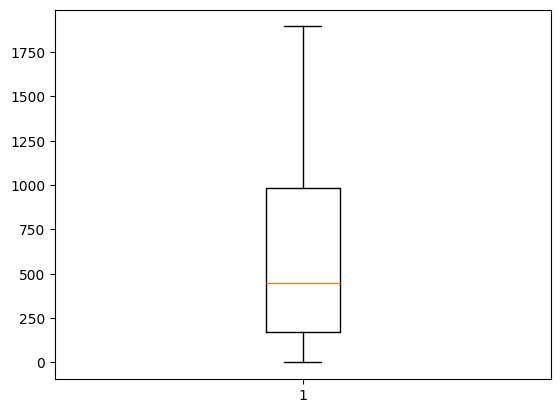

In [163]:
# Cabin_Num 이상치 확인
plt.boxplot(df_4['Cabin_Num'])
plt.show()

In [164]:
df_5 = df_4.drop(['Cabin','Cabin_Side','Cabin_Deck'], axis=1, inplace=False)
df_5.isnull().sum()

,0
PassengerId,0
CryoSleep,217
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208
Spa,183
VRDeck,188


In [165]:
# Age 결측치 : 평균값
df_5['Age'] = df_5['Age'].fillna(df_5['Age'].mean())
df_5.isnull().sum()
#print(df_5['Age'].value_counts())

# binning 처리
conditions = [(
    df_5['Age'] <= 17
),(
    (df_5['Age'] >= 18)&(df_5['Age'] <= 64)
),(
    df_5['Age'] >= 65
)]
choices = ['Yong', 'Adult', 'Senior']
df_5['Age_binned'] = np.select(conditions,choices)

#print(df_5['Age_binned'].value_counts())

# 인코딩
df_5_Age_binned_encoded = pd.get_dummies(df_5['Age_binned'], prefix='Age_binned').astype(int)
df_6 = pd.concat([df_5,df_5_Age_binned_encoded], axis=1)
df_7 = df_6.drop(['Age','Age_binned'], axis=1, inplace=False)

print(df_7.isnull().sum())
df_7.info()


PassengerId            0
CryoSleep            217
Destination          182
VIP                  203
RoomService          181
FoodCourt            183
ShoppingMall         208
Spa                  183
VRDeck               188
Transported            0
HomePlanet_Earth       0
HomePlanet_Europa      0
HomePlanet_Mars        0
Cabin_Num              0
Cabin_Side_binary      0
Cabin_Deck_A           0
Cabin_Deck_B           0
Cabin_Deck_C           0
Cabin_Deck_D           0
Cabin_Deck_E           0
Cabin_Deck_F           0
Cabin_Deck_G           0
Cabin_Deck_T           0
Age_binned_Adult       0
Age_binned_Senior      0
Age_binned_Yong        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        8693 non-null   object 
 1   CryoSleep          8476 non-null   object 
 2   Destination        8511 non-null 

In [166]:
# CryoSleep 결측치:217 object
print(df_7['CryoSleep'].value_counts())

spending_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
df_7[spending_cols] = df_7[spending_cols].fillna(0)
df_7['TotalSpend'] = df_7[spending_cols].sum(axis=1)
#print(df_7['TotalSpend'].head(20))
#display(df_7)

df_7.loc[df_7['CryoSleep'].isnull() & (df_7['TotalSpend'] == 0), 'CryoSleep'] = True
df_7.loc[df_7['CryoSleep'].isnull() & (df_7['TotalSpend'] > 0), 'CryoSleep'] = False

df_7['CryoSleep_binary'] = np.where(df_7['CryoSleep']=='False',0,1)

df_8 = df_7.drop('CryoSleep', axis=1, inplace=False)
df_8.info()

CryoSleep
False    5439
True     3037
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        8693 non-null   object 
 1   Destination        8511 non-null   object 
 2   VIP                8490 non-null   object 
 3   RoomService        8693 non-null   float64
 4   FoodCourt          8693 non-null   float64
 5   ShoppingMall       8693 non-null   float64
 6   Spa                8693 non-null   float64
 7   VRDeck             8693 non-null   float64
 8   Transported        8693 non-null   bool   
 9   HomePlanet_Earth   8693 non-null   int64  
 10  HomePlanet_Europa  8693 non-null   int64  
 11  HomePlanet_Mars    8693 non-null   int64  
 12  Cabin_Num          8693 non-null   float64
 13  Cabin_Side_binary  8693 non-null   int64  
 14  Cabin_Deck_A       8693 non-null   int64  
 15  Cabin_De

In [167]:
# Destination 결측치 최빈값
print(df_8['Destination'].value_counts())
df_8['Destination'] = df_8['Destination'].fillna(df_8['Destination'].mode()[0])
#df_8.isnull().sum()

#인코딩
df_8_Destination_encoded = pd.get_dummies(df_8['Destination'], prefix='Destination').astype(int)
df_9 = pd.concat([df_8, df_8_Destination_encoded], axis=1)
df_10 = df_9.drop('Destination', axis=1, inplace=False)
df_10


Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64


,PassengerId,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Cabin_Num,Cabin_Side_binary,Cabin_Deck_A,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_T,Age_binned_Adult,Age_binned_Senior,Age_binned_Yong,TotalSpend,CryoSleep_binary,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0001_01,False,0.0,0.0,0.0,0.0,0.0,False,0,1,0,0.0,0,0,1,0,0,0,0,0,0,1,0,0,0.0,1,0,0,1
1,0002_01,False,109.0,9.0,25.0,549.0,44.0,True,1,0,0,0.0,1,0,0,0,0,0,1,0,0,1,0,0,736.0,1,0,0,1
2,0003_01,True,43.0,3576.0,0.0,6715.0,49.0,False,0,1,0,0.0,1,1,0,0,0,0,0,0,0,1,0,0,10383.0,1,0,0,1
3,0003_02,False,0.0,1283.0,371.0,3329.0,193.0,False,0,1,0,0.0,1,1,0,0,0,0,0,0,0,1,0,0,5176.0,1,0,0,1
4,0004_01,False,303.0,70.0,151.0,565.0,2.0,True,1,0,0,1.0,1,0,0,0,0,0,1,0,0,0,0,1,1091.0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,True,0.0,6819.0,0.0,1643.0,74.0,False,0,1,0,98.0,0,1,0,0,0,0,0,0,0,1,0,0,8536.0,1,1,0,0
8689,9278_01,False,0.0,0.0,0.0,0.0,0.0,False,1,0,0,1499.0,1,0,0,0,0,0,0,1,0,1,0,0,0.0,1,0,1,0
8690,9279_01,False,0.0,0.0,1872.0,1.0,0.0,True,1,0,0,1500.0,1,0,0,0,0,0,0,1,0,1,0,0,1873.0,1,0,0,1
8691,9280_01,False,0.0,1049.0,0.0,353.0,3235.0,False,0,1,0,608.0,1,0,0,0,0,1,0,0,0,1,0,0,4637.0,1,1,0,0


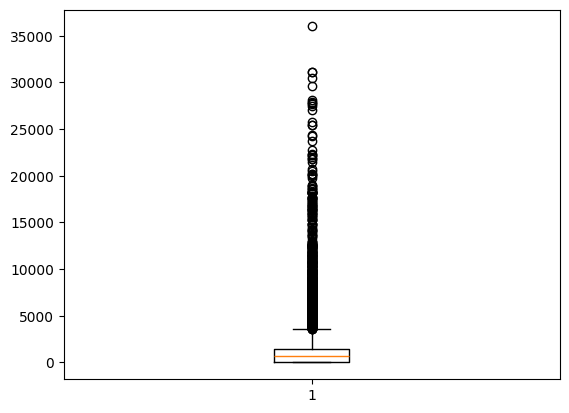

PassengerId                  0
VIP                          0
RoomService                  0
FoodCourt                    0
ShoppingMall                 0
Spa                          0
VRDeck                       0
Transported                  0
HomePlanet_Earth             0
HomePlanet_Europa            0
HomePlanet_Mars              0
Cabin_Num                    0
Cabin_Side_binary            0
Cabin_Deck_A                 0
Cabin_Deck_B                 0
Cabin_Deck_C                 0
Cabin_Deck_D                 0
Cabin_Deck_E                 0
Cabin_Deck_F                 0
Cabin_Deck_G                 0
Cabin_Deck_T                 0
Age_binned_Adult             0
Age_binned_Senior            0
Age_binned_Yong              0
TotalSpend                   0
CryoSleep_binary             0
Destination_55 Cancri e      0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
dtype: int64


In [168]:
# VIP
df_10['VIP'].value_counts()

plt.boxplot(df_10['TotalSpend'])
plt.show()

df_10.loc[df_10['VIP'].isnull() & (df_10['TotalSpend'] > 2000), 'VIP'] = True
df_10.loc[df_10['VIP'].isnull() & (df_10['TotalSpend'] <= 2000), 'VIP'] = False

print(df_10.isnull().sum())

In [170]:
df_10['VIP_binary'] = np.where(df_10['VIP']=='False',0,1)

df_11 = df_10.drop('VIP', axis=1, inplace=False)
df_11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PassengerId                8693 non-null   object 
 1   RoomService                8693 non-null   float64
 2   FoodCourt                  8693 non-null   float64
 3   ShoppingMall               8693 non-null   float64
 4   Spa                        8693 non-null   float64
 5   VRDeck                     8693 non-null   float64
 6   Transported                8693 non-null   bool   
 7   HomePlanet_Earth           8693 non-null   int64  
 8   HomePlanet_Europa          8693 non-null   int64  
 9   HomePlanet_Mars            8693 non-null   int64  
 10  Cabin_Num                  8693 non-null   float64
 11  Cabin_Side_binary          8693 non-null   int64  
 12  Cabin_Deck_A               8693 non-null   int64  
 13  Cabin_Deck_B               8693 non-null   int64

In [171]:
#Transported 타입변경

df_11['Transported'] = df_11['Transported'].astype(int)

df_11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PassengerId                8693 non-null   object 
 1   RoomService                8693 non-null   float64
 2   FoodCourt                  8693 non-null   float64
 3   ShoppingMall               8693 non-null   float64
 4   Spa                        8693 non-null   float64
 5   VRDeck                     8693 non-null   float64
 6   Transported                8693 non-null   int64  
 7   HomePlanet_Earth           8693 non-null   int64  
 8   HomePlanet_Europa          8693 non-null   int64  
 9   HomePlanet_Mars            8693 non-null   int64  
 10  Cabin_Num                  8693 non-null   float64
 11  Cabin_Side_binary          8693 non-null   int64  
 12  Cabin_Deck_A               8693 non-null   int64  
 13  Cabin_Deck_B               8693 non-null   int64

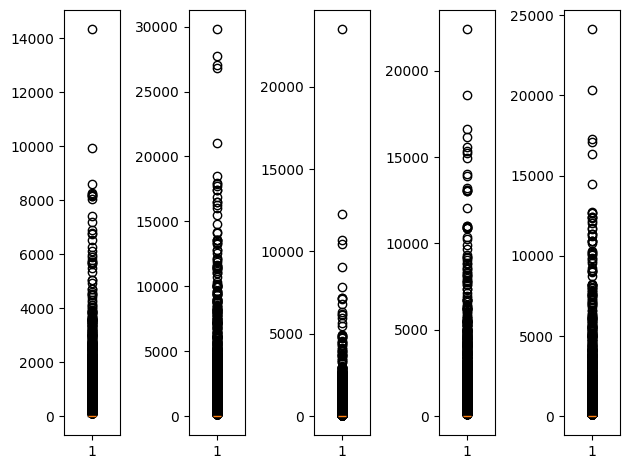

In [174]:
# 'RoomService','FoodCourt','ShoppingMall','Spa','VRDeck'
pd.set_option('display.float_format','{:.2f}'.format)
df_11.describe()

fig = plt.figure()
ax1 = fig.add_subplot(1,5,1)
ax2 = fig.add_subplot(1,5,2)
ax3 = fig.add_subplot(1,5,3)
ax4 = fig.add_subplot(1,5,4)
ax5 = fig.add_subplot(1,5,5)

ax1.boxplot(df_11['RoomService'])
ax2.boxplot(df_11['FoodCourt'])
ax3.boxplot(df_11['ShoppingMall'])
ax4.boxplot(df_11['Spa'])
ax5.boxplot(df_11['VRDeck'])
plt.tight_layout()
plt.show()

In [181]:
df_11['RoomService_log'] = np.log1p(df_11['RoomService'])
df_11['FoodCourt_log'] = np.log1p(df_11['FoodCourt'])
df_11['ShoppingMall_log'] = np.log1p(df_11['ShoppingMall'])
df_11['Spa_log'] = np.log1p(df_11['Spa'])
df_11['VRDeck_log'] = np.log1p(df_11['VRDeck'])
df_12 = df_11.drop(['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','TotalSpend'], axis=1, inplace=False)

In [194]:
# 데이터 분리
x_data = df_11.drop('Transported', axis=1, inplace=False).values
t_data = df_11['Transported'].values

# 정규화
scaler = StandardScaler()
scaler.fit(x_data)
x_data_train_norm = scaler.transform(x_data)

In [195]:
# 모델 학습
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid = GridSearchCV(XGBClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid.fit(x_data, t_data)

best_model = grid.best_estimator_

In [196]:
# 예측
predict = best_model.predict(x_data)

# 평가
print(classification_report(t_data, predict))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78      4315
           1       0.78      0.79      0.79      4378

    accuracy                           0.79      8693
   macro avg       0.79      0.79      0.79      8693
weighted avg       0.79      0.79      0.79      8693



In [185]:
# 제출파일 만들기
test = pd.read_csv('/content/drive/MyDrive/KDThome/spaceship-titanic/test.csv')
display(test.head())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.00,False,0.00,0.00,0.00,0.00,0.00,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.00,False,0.00,9.00,0.00,2823.00,0.00,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.00,False,0.00,0.00,0.00,0.00,0.00,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.00,False,0.00,6652.00,0.00,181.00,585.00,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.00,False,10.00,0.00,635.00,0.00,0.00,Brence Harperez


In [189]:
# 동일한 전처리 고고
test1 = test.drop('Name', axis=1, inplace=False)

test1['HomePlanet'] = test1['HomePlanet'].fillna(test1['HomePlanet'].mode()[0])
test1_HomePlanet_encoded = pd.get_dummies(test1['HomePlanet'], prefix='HomePlanet').astype(int)
test2 = pd.concat([test1,test1_HomePlanet_encoded], axis=1)
test3 = test2.drop('HomePlanet', axis=1, inplace=False)

test3[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = test3['Cabin'].str.split('/', expand=True)
test3['Cabin_Deck'] = test3['Cabin_Deck'].fillna(test3['Cabin_Deck'].mode()[0])
test3['Cabin_Side'] = test3['Cabin_Side'].fillna(test3['Cabin_Side'].mode()[0])
test3['Cabin_Side_binary'] = np.where(test3['Cabin_Side']=='P',0,1)
test3_Cabin_Deck_encoded = pd.get_dummies(test3['Cabin_Deck'],prefix='Cabin_Deck').astype(int)
test4 = pd.concat([test3, test3_Cabin_Deck_encoded], axis=1)
test4['Cabin_Num'] = pd.to_numeric(test4['Cabin_Num'], errors='coerce')
test4['Cabin_Num'] = test4['Cabin_Num'].fillna(test4['Cabin_Num'].mean())
test5 = test4.drop(['Cabin','Cabin_Side','Cabin_Deck'], axis=1, inplace=False)
test5['Age'] = test5['Age'].fillna(test5['Age'].mean())
conditions = [(
    test5['Age'] <= 17
),(
    (test5['Age'] >= 18)&(test5['Age'] <= 64)
),(
    test5['Age'] >= 65
)]
choices = ['Yong', 'Adult', 'Senior']
test5['Age_binned'] = np.select(conditions,choices)
test5_Age_binned_encoded = pd.get_dummies(test5['Age_binned'], prefix='Age_binned').astype(int)
test6 = pd.concat([test5,test5_Age_binned_encoded], axis=1)
test7 = test6.drop(['Age','Age_binned'], axis=1, inplace=False)

spending_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
test7[spending_cols] = test7[spending_cols].fillna(0)
test7['TotalSpend'] = test7[spending_cols].sum(axis=1)
test7.loc[test7['CryoSleep'].isnull() & (test7['TotalSpend'] == 0), 'CryoSleep'] = True
test7.loc[test7['CryoSleep'].isnull() & (test7['TotalSpend'] > 0), 'CryoSleep'] = False
test7['CryoSleep_binary'] = np.where(test7['CryoSleep']=='False',0,1)
test8 = test7.drop('CryoSleep', axis=1, inplace=False)

test8['Destination'] = test8['Destination'].fillna(test8['Destination'].mode()[0])
test8_Destination_encoded = pd.get_dummies(test8['Destination'], prefix='Destination').astype(int)
test9 = pd.concat([test8, test8_Destination_encoded], axis=1)
test10 = test9.drop('Destination', axis=1, inplace=False)

test10.loc[test10['VIP'].isnull() & (test10['TotalSpend'] > 2500), 'VIP'] = True
test10.loc[test10['VIP'].isnull() & (test10['TotalSpend'] <= 2500), 'VIP'] = False
test10['VIP_binary'] = np.where(test10['VIP']=='False',0,1)
test11 = test10.drop('VIP', axis=1, inplace=False)

test11['RoomService_log'] = np.log1p(test11['RoomService'])
test11['FoodCourt_log'] = np.log1p(test11['FoodCourt'])
test11['ShoppingMall_log'] = np.log1p(test11['ShoppingMall'])
test11['Spa_log'] = np.log1p(test11['Spa'])
test11['VRDeck_log'] = np.log1p(test11['VRDeck'])
test12 = test11.drop(['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','TotalSpend'], axis=1, inplace=False)

In [191]:
x_data_test_norm = scaler.transform(test11.values)
predict = best_model.predict(x_data_test_norm)
print(predict)

submission = pd.read_csv('/content/drive/MyDrive/KDThome/spaceship-titanic/sample_submission.csv')
display(submission.head())

[1 0 1 ... 1 1 1]


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [192]:
submission['Transported'] = predict.astype(bool)
display(submission.head())

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [193]:
# csv파일로 저장

submission.to_csv('/content/drive/MyDrive/KDThome/spaceship-titanic/myoutput.csv', index=False)